##Installing Libraries

In [ ]:
!pip install -U sentence-transformers
!pip install scikit-surprise
!pip install faiss-cpu
!pip install shap
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c3ba1bafec3c7870b3eea31b9b759c779e08133a3159ad616519119819e6aaad
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


##Importing Libraries

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as train_test_split_surprise # Renaming to avoid conflict
from sklearn.model_selection import train_test_split # Import from sklearn
from surprise import accuracy
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Flatten, Concatenate, Dropout
import faiss
import shap
from lime import lime_tabular
import json

##Loading Datasets

In [ ]:
df = pd.read_csv('/content/ex.csv')
df.head()

,Song-Name,Singer/Artists,Genre,Album/Movie,User-Rating
0,Aankh Marey,"Kumar Sanu, Mika Singh, Neha Kakkar",BollywoodDance,Simmba,8.8/10
1,Coca Cola,"Neha Kakkar, Tony Kakkar",BollywoodDanceRomantic,Luka Chuppi,9.0/10
2,Apna Time Aayega,Ranveer Singh,BollywoodDance,Gully Boy,9.7/10
3,Mungda,"Jyotica Tangri, Shaan, Subhro Ganguly",BollywoodDance,Total Dhamaal,9.1/10
4,Tere Bin,"Asees Kaur, Rahat Fateh Ali Khan, Tanishk Bagchi",BollywoodRomantic,Simmba,9.2/10


##Data Understanding

In [ ]:
print("Dataset Shape:", df.shape)
print("\nDataset Columns:", df.columns)
print("\nDataset Info:")
df.info()

Dataset Shape: (2420, 5)

Dataset Columns: Index(['Song-Name', 'Singer/Artists', 'Genre', 'Album/Movie', 'User-Rating'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2420 entries, 0 to 2419
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Song-Name       2420 non-null   object
 1   Singer/Artists  2410 non-null   object
 2   Genre           2420 non-null   object
 3   Album/Movie     2417 non-null   object
 4   User-Rating     2420 non-null   object
dtypes: object(5)
memory usage: 94.7+ KB


### Data Cleaning

Based on the `df.info()` output, we need to perform the following data cleaning steps:

1.  **Convert 'User-Rating' to numeric**: The 'User-Rating' column is currently an `object` type (string) and contains values like '8.8/10'. We need to convert this to a numeric format (e.g., float) by extracting the rating and converting it to a scale of 0-1.
2.  **Handle missing values**: The 'Singer/Artists' and 'Album/Movie' columns have a few missing values. We will fill these with 'Unknown' to ensure completeness.

In [ ]:
# Convert 'User-Rating' to numeric
df['User-Rating'] = df['User-Rating'].str.split('/').str[0].astype(float) / 10

# Fill missing values
df['Singer/Artists'] = df['Singer/Artists'].fillna('Unknown')
df['Album/Movie'] = df['Album/Movie'].fillna('Unknown')

print("Data after cleaning:")
df.info()

display(df.head())

Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2420 entries, 0 to 2419
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Song-Name       2420 non-null   object 
 1   Singer/Artists  2420 non-null   object 
 2   Genre           2420 non-null   object 
 3   Album/Movie     2420 non-null   object 
 4   User-Rating     2420 non-null   float64
dtypes: float64(1), object(4)
memory usage: 94.7+ KB


,Song-Name,Singer/Artists,Genre,Album/Movie,User-Rating
0,Aankh Marey,"Kumar Sanu, Mika Singh, Neha Kakkar",BollywoodDance,Simmba,0.88
1,Coca Cola,"Neha Kakkar, Tony Kakkar",BollywoodDanceRomantic,Luka Chuppi,0.90
2,Apna Time Aayega,Ranveer Singh,BollywoodDance,Gully Boy,0.97
3,Mungda,"Jyotica Tangri, Shaan, Subhro Ganguly",BollywoodDance,Total Dhamaal,0.91
4,Tere Bin,"Asees Kaur, Rahat Fateh Ali Khan, Tanishk Bagchi",BollywoodRomantic,Simmba,0.92


### Advanced Data Cleaning - Handling Duplicates

It's important to ensure that our dataset does not contain duplicate entries, as these can skew our analysis. We will check for and remove any full duplicate rows.

In [ ]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of duplicate rows before removal: 16
Number of rows after removing duplicates: 2404


## Exploratory Data Analysis (EDA)

Now that the data is cleaned, let's explore its characteristics. We will start by looking at the distribution of genres, artists, albums, and user ratings.

### 1. Genre Distribution

/tmp/ipykernel_7846/2763979002.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Genre', data=df, order=df['Genre'].value_counts().index, palette='viridis')


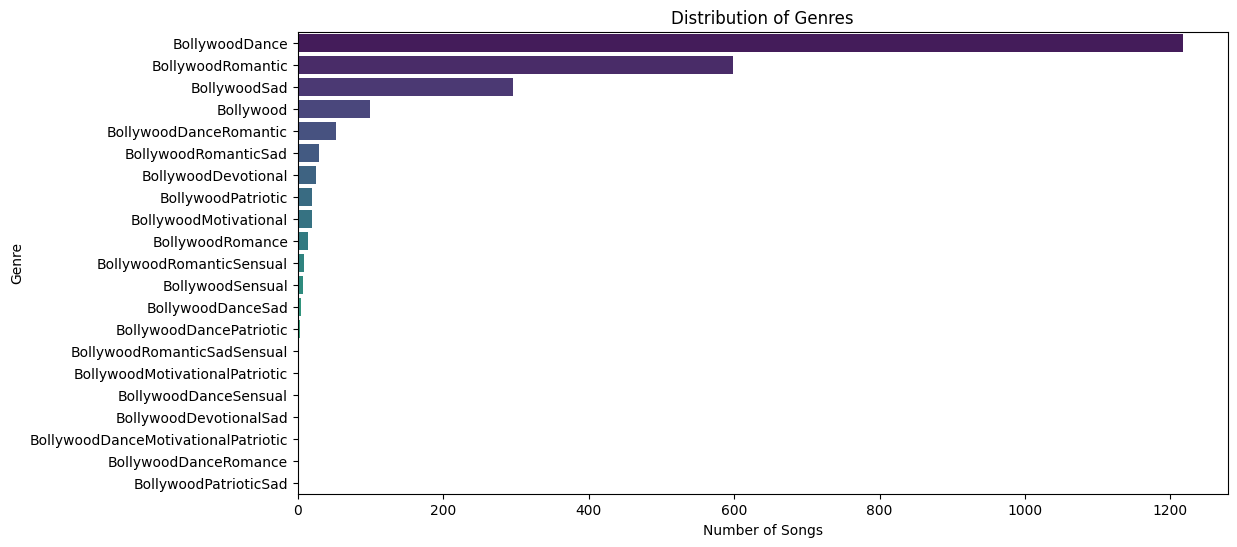

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(y='Genre', data=df, order=df['Genre'].value_counts().index, palette='viridis')
plt.title('Distribution of Genres')
plt.xlabel('Number of Songs')
plt.ylabel('Genre')
plt.show()

### 2. Top Singer/Artists

/tmp/ipykernel_7846/2647213559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Singer/Artists', data=df, order=df['Singer/Artists'].value_counts().head(15).index, palette='magma')


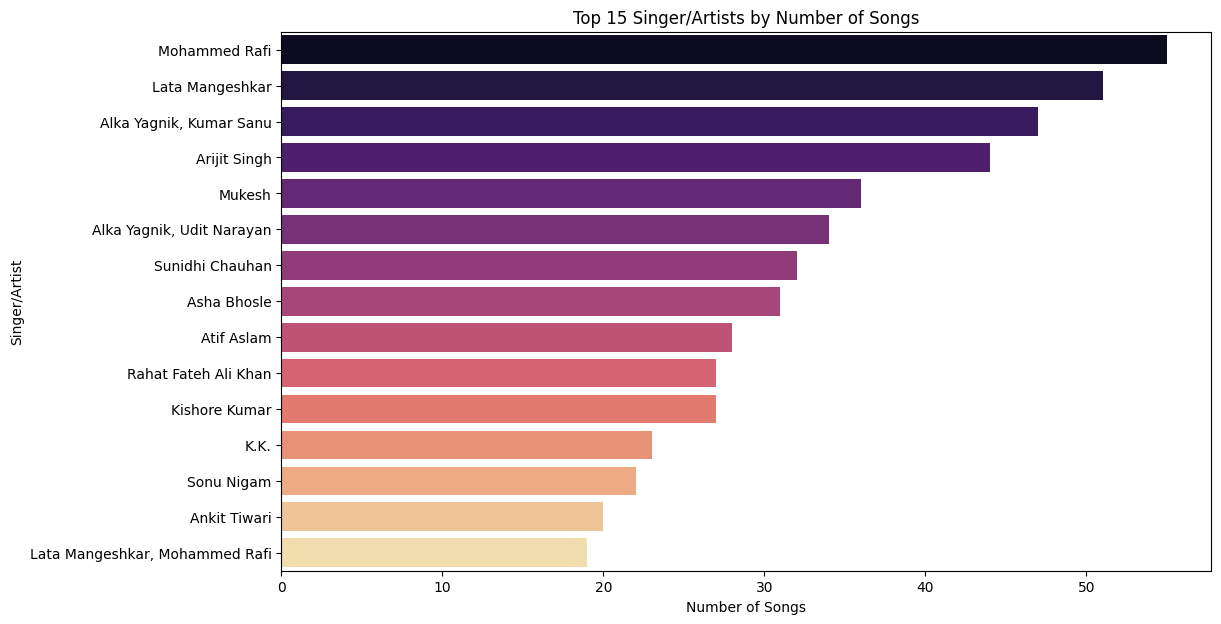

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(y='Singer/Artists', data=df, order=df['Singer/Artists'].value_counts().head(15).index, palette='magma')
plt.title('Top 15 Singer/Artists by Number of Songs')
plt.xlabel('Number of Songs')
plt.ylabel('Singer/Artist')
plt.show()

### 3. Top Albums/Movies

/tmp/ipykernel_7846/2960337389.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Album/Movie', data=df, order=df['Album/Movie'].value_counts().head(15).index, palette='crest')


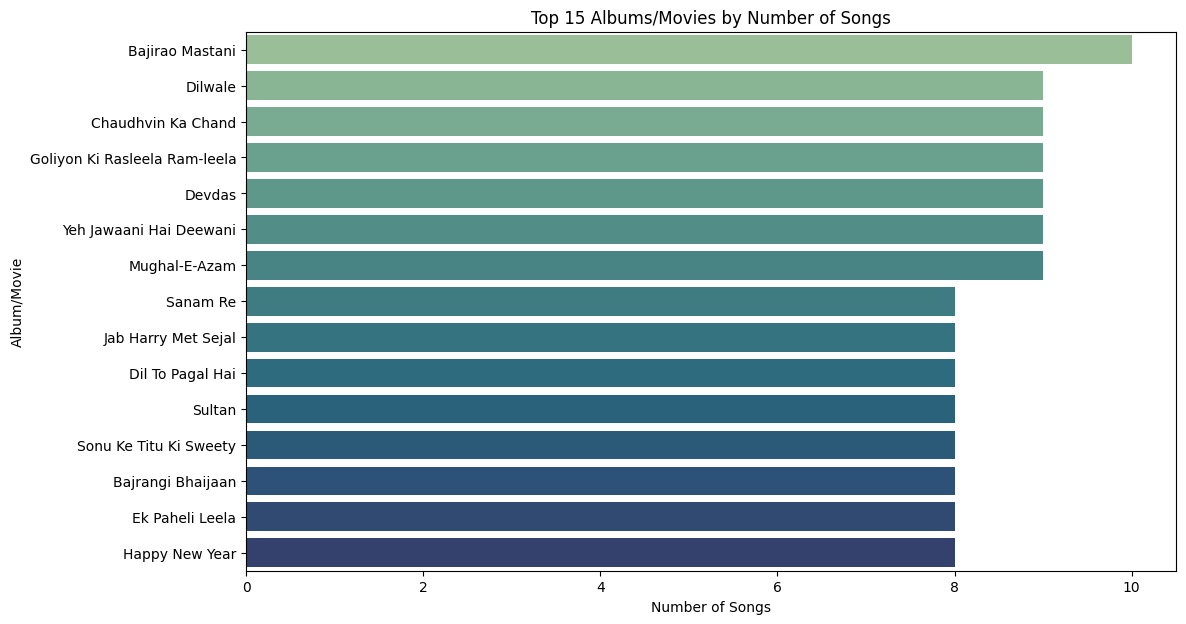

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(y='Album/Movie', data=df, order=df['Album/Movie'].value_counts().head(15).index, palette='crest')
plt.title('Top 15 Albums/Movies by Number of Songs')
plt.xlabel('Number of Songs')
plt.ylabel('Album/Movie')
plt.show()

### 4. User Rating Distribution

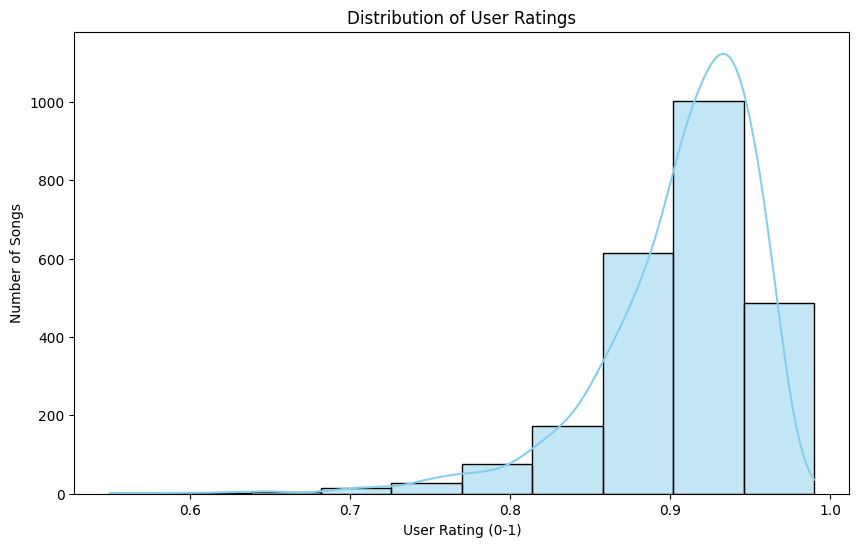

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['User-Rating'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of User Ratings')
plt.xlabel('User Rating (0-1)')
plt.ylabel('Number of Songs')
plt.show()

## Feature Engineering (Advanced)

For advanced feature engineering, we will focus on transforming the categorical `Genre` column. Since some entries combine multiple genres (e.g., 'BollywoodDanceRomantic'), we'll extract individual genre terms and create one-hot encoded features. This will provide a more detailed and numerical representation of the genre landscape, useful for further analysis or machine learning models.

In [ ]:
# Function to extract individual genres from a combined string
def extract_genres(genre_string):
    # We will split common combined genres into their constituent parts.
    # This list can be expanded based on further domain knowledge.
    # Example: 'BollywoodDanceRomantic' should become ['Bollywood', 'Dance', 'Romantic']

    # A simple approach to split based on common genre keywords in a compound string
    genre_keywords = ['Bollywood', 'Dance', 'Romantic', 'Sad', 'Devotional', 'Motivational', 'Sensual', 'Patriotic', 'Romance']

    extracted = []
    temp_genre_string = genre_string.strip()

    for keyword in genre_keywords:
        if keyword in temp_genre_string:
            extracted.append(keyword)
            # Remove the keyword to find others (this is a simple, non-overlapping approach)
            temp_genre_string = temp_genre_string.replace(keyword, '', 1)

    # If after extracting keywords, there's still a significant part of the string left
    # or if no keywords were found, treat the original string as a single genre.
    # This part might need refinement based on data specifics.
    if not extracted or len(temp_genre_string.strip()) > 0: # Check for remaining parts or if nothing was extracted
        return [genre_string.strip()]

    return list(set(extracted)) # Use set to handle potential duplicates from keywords if a genre contains a keyword multiple times

# Get all unique genre combinations
# Applying extract_genres and then exploding will get all individual genres
all_genres_split = df['Genre'].apply(extract_genres).explode().unique()

# Create a new DataFrame for one-hot encoded genres
genre_features_df_refined = pd.DataFrame(0, index=df.index, columns=all_genres_split)

# Populate the one-hot encoded DataFrame
for index, row in df.iterrows():
    genres_in_song = extract_genres(row['Genre'])
    for genre in genres_in_song:
        if genre in genre_features_df_refined.columns:
            genre_features_df_refined.loc[index, genre] = 1

# Concatenate the new refined genre features with the original DataFrame
df_fe = pd.concat([df, genre_features_df_refined], axis=1)

print("DataFrame with refined genre features (first 5 rows and genre columns):")
display(df_fe.head().filter(regex='(Song-Name|Genre|Bollywood|Dance|Romantic|Sad|Devotional|Motivational|Sensual|Patriotic|Romance)'))

DataFrame with refined genre features (first 5 rows and genre columns):


,Song-Name,Genre,Dance,Bollywood,Romantic,Devotional,Sad,Motivational,Romance,Sensual,Patriotic
0,Aankh Marey,BollywoodDance,1,1,0,0,0,0,0,0,0
1,Coca Cola,BollywoodDanceRomantic,1,1,1,0,0,0,0,0,0
2,Apna Time Aayega,BollywoodDance,1,1,0,0,0,0,0,0,0
3,Mungda,BollywoodDance,1,1,0,0,0,0,0,0,0
4,Tere Bin,BollywoodRomantic,0,1,1,0,0,0,0,0,0


### TF-IDF for 'Song-Name'

TF-IDF (Term Frequency-Inverse Document Frequency) is a numerical statistic that reflects how important a word is to a document in a collection or corpus. We'll apply this to the 'Song-Name' column to create features that capture the unique characteristics of each song title.

In [ ]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000) # Limiting features to 5000 for manageability

# Fit and transform the 'Song-Name' column
tfidf_matrix = tfidf_vectorizer.fit_transform(df_fe['Song-Name'])

# Convert the TF-IDF matrix to a DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out(), index=df_fe.index)

# Concatenate the TF-IDF features with our main DataFrame
df_fe = pd.concat([df_fe, tfidf_df], axis=1)

print("DataFrame with TF-IDF features for Song-Name (first 5 rows of TF-IDF features):")
display(df_fe.head().filter(regex='(Song-Name|dance|love|heart|dil|teri)'))

DataFrame with TF-IDF features for Song-Name (first 5 rows of TF-IDF features):


,Song-Name,dance,dancer,dil,dilbar,dilbaro,dildar,dilki,dillagi,dilli,...,dilruba,dilrubaon,dilse,love,lovely,lover,sweetheart,teri,teriyaan,teriyan
0,Aankh Marey,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Coca Cola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Apna Time Aayega,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Mungda,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Tere Bin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Sentence Transformers for 'Song-Name'

Sentence Transformers will generate dense vector embeddings for each song name. These embeddings capture the semantic meaning of the text, allowing us to find similarities between song titles that might not share common keywords but convey similar themes or styles. We will use a pre-trained model for this purpose.

In [ ]:
# Load a pre-trained Sentence Transformer model
# 'all-MiniLM-L6-v2' is a good balance of performance and speed
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for the 'Song-Name' column
song_name_embeddings = model.encode(df_fe['Song-Name'].tolist(), show_progress_bar=True)

# Convert embeddings to a DataFrame
embedding_df = pd.DataFrame(song_name_embeddings, index=df_fe.index)
embedding_df.columns = [f'song_name_embedding_{i}' for i in range(embedding_df.shape[1])]

# Concatenate the embeddings with our main DataFrame
df_fe = pd.concat([df_fe, embedding_df], axis=1)

print("DataFrame with Sentence Transformer embeddings for Song-Name (first 5 rows of embedding features):")
display(df_fe.head().filter(regex='(Song-Name|song_name_embedding_)'))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/76 [00:00<?, ?it/s]

DataFrame with Sentence Transformer embeddings for Song-Name (first 5 rows of embedding features):


,Song-Name,song_name_embedding_0,song_name_embedding_1,song_name_embedding_2,song_name_embedding_3,song_name_embedding_4,song_name_embedding_5,song_name_embedding_6,song_name_embedding_7,song_name_embedding_8,...,song_name_embedding_374,song_name_embedding_375,song_name_embedding_376,song_name_embedding_377,song_name_embedding_378,song_name_embedding_379,song_name_embedding_380,song_name_embedding_381,song_name_embedding_382,song_name_embedding_383
0,Aankh Marey,-0.073036,0.023526,0.045391,0.005248,-0.069157,-0.002904,0.077908,-0.025875,0.002320,...,0.050769,0.040270,-0.023191,-0.029300,0.022756,-0.007623,0.082259,0.059942,0.075458,-0.051938
1,Coca Cola,-0.081158,-0.024299,-0.014088,0.040373,0.078444,0.013523,0.103054,0.053515,0.003652,...,0.063057,-0.067462,-0.033580,0.044253,-0.127508,-0.022065,0.087773,-0.035057,0.144575,-0.036845
2,Apna Time Aayega,-0.118853,0.070910,-0.070673,-0.012821,-0.133118,-0.013323,0.123002,-0.022346,0.018638,...,0.002422,0.015830,0.000116,-0.056843,-0.027129,-0.033862,0.105805,-0.037609,-0.086461,-0.047659
3,Mungda,-0.042502,0.041584,0.006372,0.005610,-0.042069,-0.049416,0.099889,-0.020243,0.012241,...,-0.018938,0.005354,-0.026483,-0.008900,-0.012075,-0.034397,0.094277,-0.025529,-0.012444,0.019346
4,Tere Bin,0.025547,0.089780,-0.008147,-0.019439,-0.051813,0.006642,0.138238,0.080904,0.046968,...,0.090095,0.036450,-0.031310,-0.058669,-0.026942,0.058026,0.091919,-0.040491,0.054889,-0.075781


## Recommendation Algorithms

### 1. Content-Based Recommendation

This model will recommend songs based on their intrinsic characteristics (content). We will use the genre one-hot encodings, TF-IDF features, and Sentence Transformer embeddings of song names to build a comprehensive feature matrix. The similarity between songs will be calculated using cosine similarity.

#### 1.1 Creating the Feature Matrix

We will combine the one-hot encoded genre features, the TF-IDF features for song names, and the Sentence Transformer embeddings into a single feature matrix. This matrix will represent each song as a vector in a multi-dimensional space.

In [ ]:
# Identify all feature columns that are not original identifiers or text fields
feature_columns = [col for col in df_fe.columns if (
    col.startswith('Bollywood') or
    col in ['Dance', 'Romantic', 'Sad', 'Devotional', 'Motivational', 'Sensual', 'Patriotic', 'Romance'] or
    col in tfidf_vectorizer.get_feature_names_out().tolist() or
    col.startswith('song_name_embedding_')
)]

# Filter out any redundant columns if they exist (e.g., if original genre strings were kept)
# Ensure we only have the one-hot encoded / numerical features
feature_columns = list(set(feature_columns) - set(['Genre', 'Song-Name', 'Singer/Artists', 'Album/Movie', 'User-Rating']))

# Create the feature matrix
feature_matrix = df_fe[feature_columns]

print("Shape of the combined feature matrix:", feature_matrix.shape)
display(feature_matrix.head())

Shape of the combined feature matrix: (2404, 2955)


,song_name_embedding_370,shakira,ladka,song_name_embedding_358,pukarta,song_name_embedding_143,dhin,geet,dushman,song_name_embedding_174,...,aap,tutiya,yaara,bandeyaa,milan,milaana,barsa,gaddi,song_name_embedding_176,gawah
0,0.010797,0.0,0.0,0.005595,0.0,0.008385,0.0,0.0,0.0,0.052181,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.070500,0.0
1,0.014413,0.0,0.0,-0.045317,0.0,-0.013465,0.0,0.0,0.0,-0.041147,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.016990,0.0
2,0.038704,0.0,0.0,-0.069994,0.0,0.018113,0.0,0.0,0.0,-0.010022,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011152,0.0
3,-0.008479,0.0,0.0,-0.012995,0.0,0.000092,0.0,0.0,0.0,0.060033,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.022527,0.0
4,-0.011185,0.0,0.0,0.003339,0.0,-0.082745,0.0,0.0,0.0,0.015233,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.034236,0.0


#### 1.2 Calculating Cosine Similarity

Cosine similarity measures the cosine of the angle between two non-zero vectors. In our context, a higher cosine similarity indicates a greater degree of similarity between the song features. We will use this to find songs similar to a given song.

In [ ]:
# Calculate the cosine similarity matrix
cosine_sim = cosine_similarity(feature_matrix)

print("Shape of the cosine similarity matrix:", cosine_sim.shape)
print("First 5x5 block of the cosine similarity matrix:")
print(cosine_sim[:5, :5])

Shape of the cosine similarity matrix: (2404, 2404)
First 5x5 block of the cosine similarity matrix:
[[1.         0.47912694 0.58680056 0.55148455 0.32227263]
 [0.47912694 1.         0.46547292 0.4888974  0.49266179]
 [0.58680056 0.46547292 1.         0.59897184 0.27844664]
 [0.55148455 0.4888974  0.59897184 1.         0.29737042]
 [0.32227263 0.49266179 0.27844664 0.29737042 1.        ]]


### 1.3 Content-Based Recommendation Function

This function will take a song title as input and return a list of recommended songs based on cosine similarity.

In [ ]:
def get_content_based_recommendations(song_title, num_recommendations=5):
    # Get the index of the song that matches the title
    try:
        idx = df[df['Song-Name'] == song_title].index[0]
    except IndexError:
        return f"Song '{song_title}' not found in the dataset."

    # Get the pairwise similarity scores of all songs with that song
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the songs based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the `num_recommendations` most similar songs. Exclude the song itself.
    sim_scores = sim_scores[1:num_recommendations+1]

    # Get the song indices
    song_indices = [i[0] for i in sim_scores]

    # Return the top `num_recommendations` most similar songs
    return df['Song-Name'].iloc[song_indices].tolist()

#### Demonstration of Content-Based Recommendations

In [ ]:
# Example: Get recommendations for 'Aankh Marey'
recommended_songs = get_content_based_recommendations('Aankh Marey')

if isinstance(recommended_songs, list):
    print(f"Recommended songs for 'Aankh Marey':\n")
    for i, song in enumerate(recommended_songs):
        print(f"{i+1}. {song}")
else:
    print(recommended_songs)

Recommended songs for 'Aankh Marey':

1. A B C D E F G H
2. Ladi Re Ladi Tujhse Aankh Jo Ladi
3. Aankhon Aankhon (Remix)
4. Aakhon Aakhon
5. One Two Three Four


### 2. Collaborative Filtering

To implement Collaborative Filtering, we need user-item interaction data (user IDs, item IDs, and ratings). Since our current dataset `df` does not contain individual user ratings, we will generate synthetic user-song interaction data for demonstration purposes.

In [ ]:
# Let's assume we have 50 unique users for synthetic data
num_users = 50
user_ids = [f'user_{i}' for i in range(1, num_users + 1)]

# Create a mapping for song names to integer item IDs
song_to_item_id = {song_name: i for i, song_name in enumerate(df['Song-Name'].unique())}
item_id_to_song = {i: song_name for song_name, i in song_to_item_id.items()}

# Generate synthetic ratings
np.random.seed(42) # for reproducibility
synthetic_ratings_data = []

# Each user rates a random number of songs (e.g., between 10 and 50)
for user in user_ids:
    num_ratings = np.random.randint(10, 50)
    # Select random songs to rate
    rated_item_ids = np.random.choice(list(song_to_item_id.values()), num_ratings, replace=False)
    # Assign random ratings (e.g., between 1 and 10)
    ratings = np.random.uniform(1, 10, num_ratings)

    for item_id, rating in zip(rated_item_ids, ratings):
        synthetic_ratings_data.append({'user_id': user, 'item_id': item_id, 'rating': rating})

synthetic_ratings_df = pd.DataFrame(synthetic_ratings_data)

print("Synthetic Ratings DataFrame head:")
display(synthetic_ratings_df.head())
print("\nSynthetic Ratings DataFrame info:")
synthetic_ratings_df.info()

Synthetic Ratings DataFrame head:


,user_id,item_id,rating
0,user_1,1720,2.252782
1,user_1,2025,9.084355
2,user_1,1430,8.463992
3,user_1,2320,3.857783
4,user_1,2141,9.575178



Synthetic Ratings DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  1465 non-null   object 
 1   item_id  1465 non-null   int64  
 2   rating   1465 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 34.5+ KB


#### Building a Collaborative Filtering Model (SVD)

We will now use the `surprise` library to build a Singular Value Decomposition (SVD) based collaborative filtering model on our synthetic ratings data.

In [ ]:
# A Reader is needed to parse the file or DataFrame. Specify the rating scale.
reader = Reader(rating_scale=(1, 10))

# Load the data from the synthetic DataFrame
data = Dataset.load_from_df(synthetic_ratings_df[['user_id', 'item_id', 'rating']], reader)

# Split data into train and test sets using surprise's train_test_split
trainset, testset = train_test_split_surprise(data, test_size=0.25, random_state=42)

# Use the SVD algorithm
algo = SVD()

# Train the algorithm on the trainset
algo.fit(trainset)

# Make predictions on the testset
predictions = algo.test(testset)

# Evaluate the model
print("Model 2: Collaborative Filtering (SVD) Evaluation:")
accuracy.rmse(predictions, verbose=True)
accuracy.mae(predictions, verbose=True)

# Function to get Collaborative Filtering recommendations
def get_cf_recommendations(user_id, num_recommendations=5):
    # Get a list of all item IDs
    all_item_ids = list(item_id_to_song.keys())
    # Get items already rated by the user
    rated_items = [item_id for (item_id, _) in trainset.ur[trainset.to_inner_uid(user_id)]]

    # Predict ratings for items not yet rated by the user
    unrated_items = [item for item in all_item_ids if item not in rated_items]

    predictions = []
    for item_id in unrated_items:
        pred = algo.predict(user_id, item_id)
        predictions.append((item_id, pred.est)) # (item_id, estimated_rating)

    # Sort predictions by estimated rating in descending order
    predictions.sort(key=lambda x: x[1], reverse=True)

    # Get the top recommended songs
    recommended_songs = [item_id_to_song[item[0]] for item in predictions[:num_recommendations]]

    return recommended_songs

# Example: Get recommendations for a synthetic user
sample_user = user_ids[0] # Pick the first synthetic user
cf_recommendations = get_cf_recommendations(sample_user)

print(f"\nTop {len(cf_recommendations)} Collaborative Filtering recommendations for {sample_user}:")
for i, song in enumerate(cf_recommendations):
    print(f"{i+1}. {song}")

Model 2: Collaborative Filtering (SVD) Evaluation:
RMSE: 2.7352
MAE:  2.3918

Top 5 Collaborative Filtering recommendations for user_1:
1. O Maa Tujhe Salaam
2. Ghoomar
3. Haareya
4. Humko Tumse Ho Gaya Hai Pyar
5. ABCD


### 3. Hybrid Recommendation

Professional recommendation systems often use a hybrid approach, combining content-based and collaborative filtering techniques. We will implement a simple hybrid model that combines the scores from both our previously built models with a weighted average, as suggested.

In [ ]:
def get_hybrid_recommendations(user_id, song_title, num_recommendations=5, cf_weight=0.6, content_weight=0.4):
    # Ensure weights sum to 1
    if cf_weight + content_weight != 1.0:
        raise ValueError("Collaborative Filtering and Content-Based weights must sum to 1.0")

    # Get CF recommendations and their estimated ratings for unrated songs
    all_item_ids = list(item_id_to_song.keys())
    rated_items = set([item_id for (item_id, _) in trainset.ur[trainset.to_inner_uid(user_id)]])

    cf_predictions_map = {}
    for item_id in all_item_ids:
        if item_id not in rated_items:
            pred = algo.predict(user_id, item_id)
            cf_predictions_map[item_id_to_song[item_id]] = pred.est

    # Get Content-Based similarity scores for all songs relative to the given song_title
    try:
        idx = df[df['Song-Name'] == song_title].index[0]
    except IndexError:
        print(f"Song '{song_title}' not found in the dataset for content-based part.")
        return []

    sim_scores = list(enumerate(cosine_sim[idx]))
    content_scores_map = {df['Song-Name'].iloc[i]: score for i, score in sim_scores}

    # Combine scores
    combined_scores = {}
    for s_name in df['Song-Name'].unique():
        if s_name == song_title: # Skip the song itself
            continue

        cf_score = cf_predictions_map.get(s_name, 5.0) # Default CF score if no prediction (e.g., if song is not in synthetic data, use mid-point)
        content_score = content_scores_map.get(s_name, 0.0) # Default content score

        # Normalize CF score to 0-1 scale (assuming original ratings 1-10)
        normalized_cf_score = (cf_score - 1) / 9.0 # (rating - min_rating) / (max_rating - min_rating)

        # Combine with weights
        combined_scores[s_name] = (cf_weight * normalized_cf_score) + (content_weight * content_score)

    # Sort by combined score and return top recommendations
    sorted_recommendations = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)

    # Filter out songs that the user has already rated in the synthetic dataset
    final_recommendations = []
    current_recommended_count = 0
    for song, score in sorted_recommendations:
        # Check if the song's item_id corresponds to a rated item for the user
        if song in song_to_item_id and song_to_item_id[song] in rated_items:
            continue # Skip already rated items
        final_recommendations.append(song)
        current_recommended_count += 1
        if current_recommended_count >= num_recommendations:
            break

    return final_recommendations


# Example: Get hybrid recommendations for our sample user and a chosen song
sample_user = user_ids[0] # The same user we used for CF demo
sample_song_for_content = 'Aankh Marey' # A song to base content recommendations on

hybrid_recommendations = get_hybrid_recommendations(sample_user, sample_song_for_content)

print(f"\nTop {len(hybrid_recommendations)} Hybrid recommendations for {sample_user} (based on '{sample_song_for_content}'):")
for i, song in enumerate(hybrid_recommendations):
    print(f"{i+1}. {song}")


Top 5 Hybrid recommendations for user_1 (based on 'Aankh Marey'):
1. Ghoomar
2. ABCD
3. Humko Tumse Ho Gaya Hai Pyar
4. O Sathiya
5. Taang Uthake


### 4. Deep Learning Recommendation

For larger datasets and more complex recommendation scenarios, Deep Learning models can be very powerful. We will build a basic neural network using TensorFlow/Keras to predict the probability of a user liking a song based on user and song features (embeddings).

#### 4.1 Data Preparation for Deep Learning

We need to prepare our synthetic user-item interaction data for input into a neural network. This involves mapping user and item IDs to continuous integer indices and extracting relevant features.

In [ ]:
# Map user_id strings to integer indices
unique_user_ids = synthetic_ratings_df['user_id'].unique()
user_id_to_idx = {user_id: idx for idx, user_id in enumerate(unique_user_ids)}
idx_to_user_id = {idx: user_id for user_id, idx in user_id_to_idx.items()}

# Map item_id (which are already integers) to a contiguous range if needed,
# but our item_ids are already 0-indexed from song_to_item_id
# Max item_id is `len(df['Song-Name'].unique()) - 1`

num_users = len(unique_user_ids)
num_items = len(df['Song-Name'].unique())

# Convert user_id and item_id in synthetic_ratings_df to numerical indices
synthetic_ratings_df['user_idx'] = synthetic_ratings_df['user_id'].map(user_id_to_idx)
# item_id is already an index, no further mapping needed
synthetic_ratings_df['item_idx'] = synthetic_ratings_df['item_id']

# Prepare data for the neural network
X = synthetic_ratings_df[['user_idx', 'item_idx']].values
y = synthetic_ratings_df['rating'].values

# Normalize ratings to a 0-1 scale for the neural network output (if predicting probability/normalized rating)
y_normalized = (y - y.min()) / (y.max() - y.min())

# Split data into training and testing sets using sklearn's train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_normalized, test_size=0.2, random_state=42)

print(f"Number of unique users: {num_users}")
print(f"Number of unique items: {num_items}")
print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

# Display a few processed rows
print("\nProcessed Synthetic Ratings DataFrame head:")
display(synthetic_ratings_df.head())

Number of unique users: 50
Number of unique items: 2337
Shape of X_train: (1172, 2), y_train: (1172,)
Shape of X_test: (293, 2), y_test: (293,)

Processed Synthetic Ratings DataFrame head:


,user_id,item_id,rating,user_idx,item_idx
0,user_1,1720,2.252782,0,1720
1,user_1,2025,9.084355,0,2025
2,user_1,1430,8.463992,0,1430
3,user_1,2320,3.857783,0,2320
4,user_1,2141,9.575178,0,2141


#### 4.2 Building the Deep Learning Model

We'll create a neural network model with embedding layers for users and items, followed by dense layers to predict the normalized rating.

In [ ]:
# Hyperparameters for the embedding layers
embedding_dim = 50 # Dimension of the embedding space

# Input layers
user_input = Input(shape=(1,), name='user_input')
item_input = Input(shape=(1,), name='item_input')

# Embedding layers
user_embedding = Embedding(input_dim=num_users, output_dim=embedding_dim, input_length=1, name='user_embedding')(user_input)
item_embedding = Embedding(input_dim=num_items, output_dim=embedding_dim, input_length=1, name='item_embedding')(item_input)

# Flatten embeddings
user_vec = Flatten(name='flatten_user')(user_embedding)
item_vec = Flatten(name='flatten_item')(item_embedding)

# Concatenate user and item embeddings
concat = Concatenate()([user_vec, item_vec])

# Dense layers
dense1 = Dense(128, activation='relu')(concat)
dropout1 = Dropout(0.2)(dense1)
dense2 = Dense(64, activation='relu')(dropout1)
dropout2 = Dropout(0.2)(dense2)

# Output layer (predicting a rating between 0 and 1, using sigmoid)
output = Dense(1, activation='sigmoid')(dropout2)

# Create the model
dl_model = Model(inputs=[user_input, item_input], outputs=output)

# Compile the model
dl_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

# Print model summary
dl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 50)     │      2,500 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 50)     │    116,850 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_user        │ (None, 50)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_item        │ (None, 50)        │          0 │ item_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 100)       │          0 │ flatten_user[0][… │
│ (Concatenate)       │                   │            │ flatten_item[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     12,928 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 140,599 (549.21 KB)

 Trainable params: 140,599 (549.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0840 - mean_absolute_error: 0.2521 - val_loss: 0.0914 - val_mean_absolute_error: 0.2646
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0822 - mean_absolute_error: 0.2487 - val_loss: 0.0919 - val_mean_absolute_error: 0.2661
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0787 - mean_absolute_error: 0.2418 - val_loss: 0.0942 - val_mean_absolute_error: 0.2710
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0673 - mean_absolute_error: 0.2204 - val_loss: 0.1051 - val_mean_absolute_error: 0.2874
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0431 - mean_absolute_error: 0.1662 - val_loss: 0.1349 - val_mean_absolute_error: 0.3138
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0281 - mean_absolute_error: 0.1271 - val_loss: 0.1450 - val_mean_absolute_error: 0.3205
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0236 - mean_absolute_error: 0.1120 - val_loss: 0.13

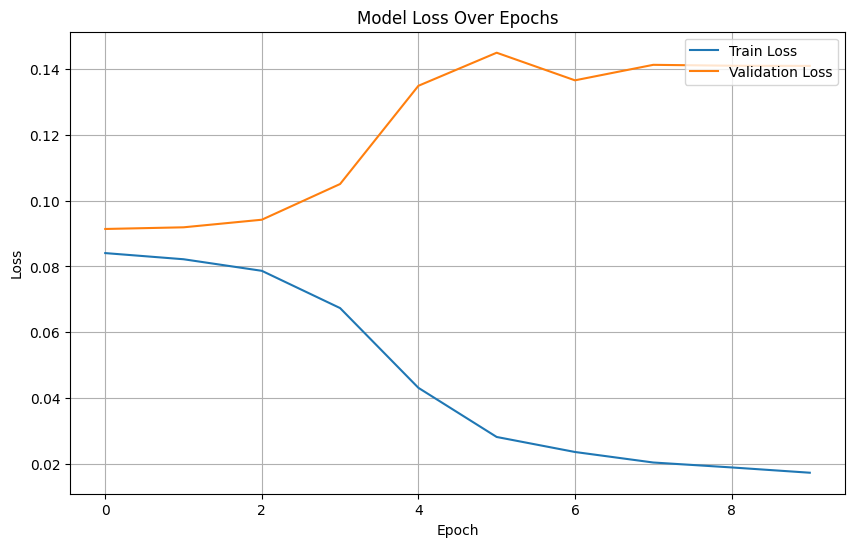

In [ ]:
history = dl_model.fit(
    [X_train[:, 0], X_train[:, 1]],
    y_train,
    epochs=10, # You can adjust the number of epochs
    batch_size=64,
    validation_split=0.1, # Use a small portion of training data for validation during training
    verbose=1
)

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

#### 4.3 Training the Deep Learning Model

We will now train our neural network using the prepared training data.

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0159 - mean_absolute_error: 0.0894 - val_loss: 0.1408 - val_mean_absolute_error: 0.3206
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0140 - mean_absolute_error: 0.0833 - val_loss: 0.1410 - val_mean_absolute_error: 0.3197
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0134 - mean_absolute_error: 0.0816 - val_loss: 0.1417 - val_mean_absolute_error: 0.3208
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0119 - mean_absolute_error: 0.0760 - val_loss: 0.1404 - val_mean_absolute_error: 0.3196
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0100 - mean_absolute_error: 0.0700 - val_loss: 0.1416 - val_mean_absolute_error: 0.3204
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0088 - mean_absolute_error: 0.0672 - val_loss: 0.1447 - val_mean_absolute_error: 0.3238
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0084 - mean_absolute_error: 0.0661 - val_loss: 0.14

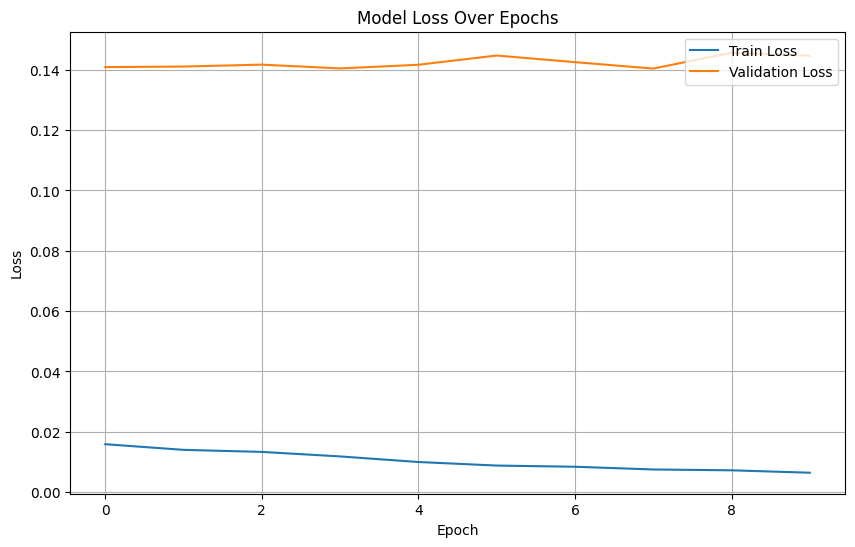

In [ ]:
history = dl_model.fit(
    [X_train[:, 0], X_train[:, 1]],
    y_train,
    epochs=10, # You can adjust the number of epochs
    batch_size=64,
    validation_split=0.1, # Use a small portion of training data for validation during training
    verbose=1
)

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

#### 4.4 Evaluating the Deep Learning Model

Let's evaluate the performance of our Deep Learning model on the test set.

In [ ]:
loss, mae = dl_model.evaluate([X_test[:, 0], X_test[:, 1]], y_test, verbose=0)
print(f"Deep Learning Model Evaluation:\nTest Loss (MSE): {loss:.4f}\nTest MAE: {mae:.4f}")

Deep Learning Model Evaluation:
Test Loss (MSE): 0.1232
Test MAE: 0.2921


#### 4.5 Deep Learning Recommendation Function

Now, let's create a function to generate recommendations using our trained deep learning model.

In [ ]:
def get_dl_recommendations(user_id, num_recommendations=5):
    if user_id not in user_id_to_idx:
        return f"User '{user_id}' not found in the dataset."

    user_idx = user_id_to_idx[user_id]

    # Get all item indices
    all_item_indices = np.arange(num_items)

    # Create a batch of (user_idx, item_idx) pairs for prediction
    user_input_batch = np.full(num_items, user_idx)
    item_input_batch = all_item_indices

    # Predict ratings for all items for the given user
    predicted_ratings_normalized = dl_model.predict([user_input_batch, item_input_batch], verbose=0)

    # Scale predictions back to original rating range (1-10) for easier interpretation
    min_original_rating = synthetic_ratings_df['rating'].min()
    max_original_rating = synthetic_ratings_df['rating'].max()
    predicted_ratings = predicted_ratings_normalized * (max_original_rating - min_original_rating) + min_original_rating

    # Combine item indices with their predicted ratings
    item_ratings = list(zip(all_item_indices, predicted_ratings.flatten()))

    # Sort items by predicted rating in descending order
    item_ratings.sort(key=lambda x: x[1], reverse=True)

    # Exclude items the user has already rated in the synthetic data
    user_rated_items = synthetic_ratings_df[synthetic_ratings_df['user_id'] == user_id]['item_idx'].tolist()

    recommended_songs = []
    for item_idx, predicted_rating in item_ratings:
        if item_idx not in user_rated_items:
            song_name = item_id_to_song[item_idx]
            recommended_songs.append((song_name, predicted_rating))
            if len(recommended_songs) >= num_recommendations:
                break

    return recommended_songs

# Example: Get Deep Learning recommendations for our sample user
sample_user = user_ids[0] # The same user we used for CF demo
dl_recommendations = get_dl_recommendations(sample_user)

print(f"\nTop {len(dl_recommendations)} Deep Learning recommendations for {sample_user}:")
for i, (song, rating) in enumerate(dl_recommendations):
    print(f"{i+1}. {song} (Predicted Rating: {rating:.2f})")


Top 5 Deep Learning recommendations for user_1:
1. Jag Soona Soona Lage (Predicted Rating: 5.56)
2. Aao Bachho Tumhe Dikhaye (Predicted Rating: 5.56)
3. Dekha Hazaro Dafaa (Predicted Rating: 5.55)
4. Party Chale On (Predicted Rating: 5.55)
5. Dance Pe Chance (Predicted Rating: 5.55)


## Resources: Semantic Search with FAISS

This section will implement a semantic search system for songs using FAISS, leveraging the Sentence Transformer embeddings. This approach allows for very fast retrieval of similar songs, even with large datasets.

### 1. Initialize FAISS Index and Add Vectors

We will use the Sentence Transformer embeddings generated earlier (`song_name_embeddings`) and store them in a FAISS index for efficient similarity search. We'll use an `IndexFlatL2` which is suitable for exact nearest neighbor search based on L2 distance.

In [ ]:
# Get the dimension of the embeddings
dimension = song_name_embeddings.shape[1]

# Initialize a FAISS index (IndexFlatL2 for Euclidean distance)
index = faiss.IndexFlatL2(dimension)

# Add the song embeddings to the index
index.add(np.array(song_name_embeddings).astype('float32'))

print(f"FAISS index created with {index.ntotal} vectors of dimension {dimension}.")

FAISS index created with 2404 vectors of dimension 384.


### 2. FAISS Search Function

This function will take a user query (song name or text) and return the most similar songs from our dataset using the FAISS index. It will first convert the query into an embedding using the same Sentence Transformer model and then search the FAISS index.

In [ ]:
def faiss_search_recommendations(query_text, num_recommendations=5, top_n_faiss=50):
    # Encode the query text using the same Sentence Transformer model
    query_embedding = model.encode([query_text]).astype('float32')

    # Perform a search in the FAISS index
    # D: distances, I: indices of the nearest neighbors
    distances, indices = index.search(query_embedding, top_n_faiss)

    # Retrieve the song names corresponding to the indices
    # Exclude the query song itself if it's perfectly matched (distance 0)
    recommended_song_indices = []
    for i in indices[0]:
        if df_fe['Song-Name'].iloc[i].lower() != query_text.lower(): # Avoid recommending the exact query song
            recommended_song_indices.append(i)
        if len(recommended_song_indices) >= num_recommendations:
            break

    return df_fe['Song-Name'].iloc[recommended_song_indices].tolist()

# Example usage:
query = "party songs"
faiss_recs = faiss_search_recommendations(query)

print(f"\nTop {len(faiss_recs)} songs semantically similar to '{query}':")
for i, song in enumerate(faiss_recs):
    print(f"{i+1}. {song}")

query_song_name = "Coca Cola"
faiss_recs_song = faiss_search_recommendations(query_song_name)

print(f"\nTop {len(faiss_recs_song)} songs semantically similar to the song '{query_song_name}':")
for i, song in enumerate(faiss_recs_song):
    print(f"{i+1}. {song}")


Top 5 songs semantically similar to 'party songs':
1. Party On My Mind (Remix)
2. Party All Night (Remix)
3. Party On My Mind
4. Party All Night
5. Party All Night

Top 5 songs semantically similar to the song 'Coca Cola':
1. Alcoholic
2. Billionaire
3. Jingle Jingle
4. Beedi
5. Thug Le


## Explainable AI (XAI)

Explainable AI (XAI) refers to methods and techniques that allow human users to understand the output of AI models. In the context of recommendation systems, XAI helps us answer the crucial question: "Why was this song recommended to me?"

Providing explanations for recommendations fosters trust, transparency, and can even improve user satisfaction by helping users discover new content or understand their own preferences better.

We will implement XAI for our different recommendation models, starting with the Content-Based Recommendation, which is inherently more interpretable.

### 1. Explaining Content-Based Recommendations

For content-based recommendations, the explanations naturally stem from the shared characteristics between the query song and the recommended songs. We can highlight common genres and the overall semantic similarity captured by the Sentence Transformer embeddings. Since the model uses these explicit features for similarity, explaining its recommendations is quite direct.

In [ ]:
def get_content_based_explanations(query_song_title, recommended_songs):
    explanations = []
    try:
        query_song_idx = df_fe[df_fe['Song-Name'] == query_song_title].index[0]
    except IndexError:
        return [f"Query song '{query_song_title}' not found in the dataset for explanation."]

    # Get the list of genre columns from the refined genre features
    genre_cols = [col for col in ['Dance', 'Bollywood', 'Romantic', 'Devotional', 'Sad', 'Motivational', 'Romance', 'Sensual', 'Patriotic'] if col in df_fe.columns]

    query_genres = [col for col in genre_cols if df_fe.loc[query_song_idx, col] == 1]

    for rec_song_name in recommended_songs:
        try:
            rec_song_idx = df_fe[df_fe['Song-Name'] == rec_song_name].index[0]
        except IndexError:
            explanations.append(f"Recommended song '{rec_song_name}' not found in the dataset for explanation.")
            continue

        rec_genres = [col for col in genre_cols if df_fe.loc[rec_song_idx, col] == 1]

        common_genres = list(set(query_genres).intersection(rec_genres))

        explanation_text = f"**'{rec_song_name}'** is recommended because:\n"
        if common_genres:
            explanation_text += f"  ✓ **Similar Genre(s)**: {', '.join(common_genres)}\n"
        else:
            # If no exact genre overlap, still possible to be similar overall in content
            explanation_text += f"  ✓ **Similar Genre Profile**: Shares underlying characteristics with '{query_song_title}'.\n"

        # All content-based recommendations implicitly use semantic similarity from sentence transformers
        explanation_text += "  ✓ **Semantic Similarity**: The song name is semantically similar (identified by advanced NLP embeddings).\n"
        # You could also add TF-IDF keyword similarity if desired, but semantic covers broader meaning

        explanations.append(explanation_text)
    return explanations

# --- Demonstration ---
query_song_for_explanation = 'Aankh Marey'

# First, get the content-based recommendations (e.g., top 3 for brevity)
recommended_songs_cb = get_content_based_recommendations(query_song_for_explanation, num_recommendations=3)

if isinstance(recommended_songs_cb, list) and recommended_songs_cb:
    print(f"\nContent-Based Recommendations and Explanations for '{query_song_for_explanation}':")
    cb_explanations = get_content_based_explanations(query_song_for_explanation, recommended_songs_cb)
    for explanation in cb_explanations:
        print(explanation)
        print("-" * 50) # Separator for readability
elif recommended_songs_cb:
    print(recommended_songs_cb) # In case of an error message string
else:
    print(f"No content-based recommendations found for '{query_song_for_explanation}'.")


Content-Based Recommendations and Explanations for 'Aankh Marey':
**'A B C D E F G H'** is recommended because:
  ✓ **Similar Genre(s)**: Dance, Bollywood
  ✓ **Semantic Similarity**: The song name is semantically similar (identified by advanced NLP embeddings).

--------------------------------------------------
**'Ladi Re Ladi Tujhse Aankh Jo Ladi'** is recommended because:
  ✓ **Similar Genre(s)**: Dance, Bollywood
  ✓ **Semantic Similarity**: The song name is semantically similar (identified by advanced NLP embeddings).

--------------------------------------------------
**'Aankhon Aankhon (Remix)'** is recommended because:
  ✓ **Similar Genre(s)**: Dance, Bollywood
  ✓ **Semantic Similarity**: The song name is semantically similar (identified by advanced NLP embeddings).

--------------------------------------------------


### 2. Explaining Collaborative Filtering (SVD) Recommendations

The SVD model in collaborative filtering relies on latent factors derived from user-item interaction patterns, rather than explicit song features like genres or semantic similarity. This makes direct, intuitive 'feature-based' explanations (like those produced by SHAP/LIME on explicit features) challenging for individual predictions. The "features" here are abstract latent dimensions.

Instead, explanations for collaborative filtering are typically rooted in **user behavior** and **similarity of preferences**. We explain a recommendation by highlighting that users with similar tastes (who have rated similar items highly) have also rated the recommended song highly. It's essentially a form of "people like you liked this" explanation.

In [ ]:
# Get some of the sample user's top rated songs for context in explanation
sample_user_id = user_ids[0]
user_rated_songs = synthetic_ratings_df[synthetic_ratings_df['user_id'] == sample_user_id].copy()
# Map item_id back to song name
user_rated_songs['song_name'] = user_rated_songs['item_id'].map(item_id_to_song)
top_rated_by_user = user_rated_songs.sort_values(by='rating', ascending=False).head(3)['song_name'].tolist()

print(f"\n--- Collaborative Filtering (SVD) Explanations for {sample_user_id} ---")
print("The SVD model for collaborative filtering focuses on latent factors derived from user-item interactions, making direct 'feature-based' explanations (like SHAP/LIME) challenging to interpret intuitively for individual predictions.")
print("\nInstead, CF recommendations are typically explained by highlighting similar user preferences or item popularity among similar users.")
print(f"For {sample_user_id}, who has highly rated songs like: {', '.join(top_rated_by_user)},\n")

cf_recommendations = get_cf_recommendations(sample_user_id)
for i, song in enumerate(cf_recommendations):
    print(f"**'{song}'** is recommended because:")
    print(f"  ✓ **Similar User Behavior**: The model predicts you would like this song based on what other users with similar taste patterns (who also liked songs you enjoy) have rated highly.")
    print(f"  ✓ **Predicted Rating**: The model estimated a high likelihood of you enjoying this song.")
    print("-" * 50)



--- Collaborative Filtering (SVD) Explanations for user_1 ---
The SVD model for collaborative filtering focuses on latent factors derived from user-item interactions, making direct 'feature-based' explanations (like SHAP/LIME) challenging to interpret intuitively for individual predictions.

Instead, CF recommendations are typically explained by highlighting similar user preferences or item popularity among similar users.
For user_1, who has highly rated songs like: Lage Na Mora Jiya, O Maa Tujhe Salaam, O Basanti Pavan,

**'O Maa Tujhe Salaam'** is recommended because:
  ✓ **Similar User Behavior**: The model predicts you would like this song based on what other users with similar taste patterns (who also liked songs you enjoy) have rated highly.
  ✓ **Predicted Rating**: The model estimated a high likelihood of you enjoying this song.
--------------------------------------------------
**'Ghoomar'** is recommended because:
  ✓ **Similar User Behavior**: The model predicts you would l

### 3. Explaining Deep Learning Recommendations using SHAP

The Deep Learning model, with its embedding layers and dense neural network, is a good candidate for applying SHAP (SHapley Additive exPlanations). SHAP provides a way to explain individual predictions by showing how much each feature contributes to the prediction, compared to the average prediction.

For our Deep Learning model, the 'features' that influence the final prediction are the learned embedding vectors for users and items. We will use SHAP to attribute the predicted rating to the dimensions within these concatenated user and item embeddings. While interpreting individual dimensions of an embedding vector can be abstract, SHAP helps quantify their importance.

In [ ]:
# Create a sub-model that takes concatenated embeddings as input
# and outputs the final prediction. This allows SHAP to focus on the
# dense layers after embeddings.
dl_expl_input = tf.keras.Input(shape=(embedding_dim * 2,)) # user_embedding_dim + item_embedding_dim
x = tf.keras.layers.Dense(128, activation='relu', name='dense1_expl')(dl_expl_input)
x = tf.keras.layers.Dropout(0.2, name='dropout1_expl')(x)
x = tf.keras.layers.Dense(64, activation='relu', name='dense2_expl')(x)
x = tf.keras.layers.Dropout(0.2, name='dropout2_expl')(x)
dl_expl_output = tf.keras.layers.Dense(1, activation='sigmoid', name='output_expl')(x)
dl_explainer_model = tf.keras.Model(inputs=dl_expl_input, outputs=dl_expl_output)

# Transfer weights from the original model to the explainer model
dl_explainer_model.get_layer('dense1_expl').set_weights(dl_model.get_layer('dense_3').get_weights())
dl_explainer_model.get_layer('dense2_expl').set_weights(dl_model.get_layer('dense_4').get_weights())
dl_explainer_model.get_layer('output_expl').set_weights(dl_model.get_layer('dense_5').get_weights())

# The prediction function for SHAP. It must take a 2D array of samples.
def dl_shap_predict(X_concatenated_embeddings):
    return dl_explainer_model.predict(X_concatenated_embeddings, verbose=0)

# Select a prediction to explain
sample_user_id = user_ids[0]
sample_user_idx = user_id_to_idx[sample_user_id]

# Let's pick one of the top DL recommendations for this user
dl_recs = get_dl_recommendations(sample_user_id, num_recommendations=1)

if not dl_recs:
    print(f"No Deep Learning recommendations found to explain for user {sample_user_id}.")
else:
    recommended_song_name, predicted_rating = dl_recs[0]
    recommended_item_id = song_to_item_id[recommended_song_name]
    # item_id from song_to_item_id is already the index for embedding lookup
    recommended_item_idx = recommended_item_id

    print(f"\n--- Deep Learning (DL) Explanations for '{recommended_song_name}' to '{sample_user_id}' ---")
    print(f"Predicted Rating: {predicted_rating:.2f}")

    # Extract the embeddings for the specific user and item
    user_embedding_vector = dl_model.get_layer('user_embedding').get_weights()[0][sample_user_idx]
    item_embedding_vector = dl_model.get_layer('item_embedding').get_weights()[0][recommended_item_idx]

    # Feature vector for the prediction we want to explain (single sample)
    X_explain = np.concatenate([user_embedding_vector, item_embedding_vector]).reshape(1, -1)

    # Create a background dataset for SHAP (representative sample of concatenated embeddings)
    num_background_samples = 100 # Adjust as needed for performance/accuracy
    background_indices = np.random.choice(len(synthetic_ratings_df), num_background_samples, replace=False)

    background_user_indices = synthetic_ratings_df.iloc[background_indices]['user_idx'].values
    background_item_indices = synthetic_ratings_df.iloc[background_indices]['item_idx'].values

    # Extract background embeddings
    background_user_embeddings = dl_model.get_layer('user_embedding').get_weights()[0][background_user_indices]
    background_item_embeddings = dl_model.get_layer('item_embedding').get_weights()[0][background_item_indices]

    X_background = np.concatenate([background_user_embeddings, background_item_embeddings], axis=1)

    # Run SHAP KernelExplainer
    # KernelExplainer can use our custom dl_shap_predict function.
    explainer = shap.KernelExplainer(dl_shap_predict, X_background)
    shap_values = explainer.shap_values(X_explain)

    # The features are the dimensions of the concatenated embedding vectors.
    feature_names = [f'user_emb_{i}' for i in range(embedding_dim)] + \
                    [f'item_emb_{i}' for i in range(embedding_dim)]

    print(f"\nSHAP explanation for Deep Learning recommendation of '{recommended_song_name}' to '{sample_user_id}':")

    # SHAP values for a single prediction are typically returned as a list if multi-output, or an array if single-output
    if isinstance(shap_values, list):
        # Take the first output, and first sample, then flatten to 1D
        shap_values_plot = shap_values[0][0].flatten()
    else:
        # For single output, single sample, flatten to 1D
        shap_values_plot = shap_values[0].flatten()

    # Display top contributing features (by absolute SHAP value)
    sorted_indices = np.argsort(np.abs(shap_values_plot))[::-1]
    top_features_count = 10 # Display top 10 contributing features

    print(f"\nTop {top_features_count} contributing features (embedding dimensions) for this prediction:")
    for i in range(top_features_count):
        idx = sorted_indices[i]
        feature_name = feature_names[idx]
        shap_value = shap_values_plot[idx]
        print(f"  ✓ {feature_name}: {shap_value:.4f}")

    print("\nInterpretation: Each 'user_emb_X' and 'item_emb_Y' represents a latent dimension (an abstract characteristic) learned by the Deep Learning model. The SHAP values indicate how much each of these latent dimensions contributes to pushing the predicted rating higher or lower for this specific recommendation. A positive SHAP value means that dimension contributed to a higher predicted rating, and a negative value to a lower one. While individual dimensions are not directly interpretable as 'genre' or 'mood', their collective influence determines the recommendation.")


--- Deep Learning (DL) Explanations for 'Tum Dil Ki Dhadkan Mein' to 'user_1' ---
Predicted Rating: 9.75


  0%|          | 0/1 [00:00<?, ?it/s]


SHAP explanation for Deep Learning recommendation of 'Tum Dil Ki Dhadkan Mein' to 'user_1':

Top 10 contributing features (embedding dimensions) for this prediction:
  ✓ item_emb_5: 0.0578
  ✓ item_emb_10: 0.0538
  ✓ item_emb_38: 0.0532
  ✓ item_emb_27: 0.0516
  ✓ item_emb_32: 0.0508
  ✓ item_emb_6: 0.0504
  ✓ item_emb_45: 0.0495
  ✓ item_emb_30: 0.0461
  ✓ item_emb_1: 0.0434
  ✓ item_emb_42: 0.0428

Interpretation: Each 'user_emb_X' and 'item_emb_Y' represents a latent dimension (an abstract characteristic) learned by the Deep Learning model. The SHAP values indicate how much each of these latent dimensions contributes to pushing the predicted rating higher or lower for this specific recommendation. A positive SHAP value means that dimension contributed to a higher predicted rating, and a negative value to a lower one. While individual dimensions are not directly interpretable as 'genre' or 'mood', their collective influence determines the recommendation.


### 4. Explaining Deep Learning Recommendations using LIME

While SHAP provides global consistency and theoretical guarantees, LIME (Local Interpretable Model-agnostic Explanations) offers another perspective by explaining individual predictions locally. LIME works by perturbing the input of the original model and observing how the predictions change. It then fits a simple, interpretable model (like a linear model) to these perturbed data points and their corresponding predictions, weighted by their proximity to the instance being explained.

For our Deep Learning model, LIME will also help us understand the impact of the latent embedding dimensions on a specific prediction. The challenge here, similar to SHAP, is that the 'features' are abstract embedding dimensions, making direct human interpretation difficult without further mapping to human-understandable song attributes.

In [ ]:
# LIME requires a prediction function that takes numpy arrays and outputs probabilities/scores.
# Our dl_shap_predict function already fits this requirement.

# Create a LIME Tabular Explainer
# The training_data is used by LIME to understand the feature distribution.
# We can use X_background that we already created for SHAP.
# feature_names are also already defined.

# Note: LIME TabularExplainer expects the feature names to correspond to columns in training_data.
# For our case, feature_names are abstract embedding dimensions, and X_background is the concatenated embeddings.

explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_background,
    feature_names=feature_names,
    class_names=['predicted_rating'], # Or a range of ratings
    mode='regression' # Since we are predicting a rating
)

# Select the same prediction to explain as for SHAP
sample_user_id = user_ids[0]
sample_user_idx = user_id_to_idx[sample_user_id]

dl_recs_lime = get_dl_recommendations(sample_user_id, num_recommendations=1)

if not dl_recs_lime:
    print(f"No Deep Learning recommendations found to explain for user {sample_user_id}.")
else:
    recommended_song_name_lime, predicted_rating_lime = dl_recs_lime[0]
    recommended_item_id_lime = song_to_item_id[recommended_song_name_lime]
    recommended_item_idx_lime = recommended_item_id_lime

    print(f"\n--- Deep Learning (DL) Explanations with LIME for '{recommended_song_name_lime}' to '{sample_user_id}' ---")
    print(f"Predicted Rating: {predicted_rating_lime:.2f}")

    # Extract the embeddings for the specific user and item for LIME
    user_embedding_vector_lime = dl_model.get_layer('user_embedding').get_weights()[0][sample_user_idx]
    item_embedding_vector_lime = dl_model.get_layer('item_embedding').get_weights()[0][recommended_item_idx_lime]

    # Feature vector for the prediction we want to explain (single sample)
    X_explain_lime = np.concatenate([user_embedding_vector_lime, item_embedding_vector_lime]).reshape(1, -1)[0] # LIME expects a 1D array for a single instance

    # Generate explanation
    # `num_features` specifies how many features to include in the explanation.
    lime_explanation = explainer_lime.explain_instance(
        data_row=X_explain_lime,
        predict_fn=dl_shap_predict,
        num_features=10
    )

    print(f"\nLIME explanation for Deep Learning recommendation of '{recommended_song_name_lime}' to '{sample_user_id}':")
    for feature, weight in lime_explanation.as_list():
        print(f"  ✓ {feature}: {weight:.4f}")

    print("\nInterpretation: LIME provides a local linear approximation of the Deep Learning model for this specific prediction. The weights indicate the contribution of each embedding dimension to the predicted rating. A positive weight means that the presence of that latent dimension (within its local context) increases the predicted rating, and a negative weight decreases it. Similar to SHAP, these are abstract dimensions, but LIME's strength is explaining *why* a particular prediction was made for a single instance by highlighting the most influential features locally.")


--- Deep Learning (DL) Explanations with LIME for 'Tum Dil Ki Dhadkan Mein' to 'user_1' ---
Predicted Rating: 9.75

LIME explanation for Deep Learning recommendation of 'Tum Dil Ki Dhadkan Mein' to 'user_1':
  ✓ item_emb_5 <= -0.03: 0.0674
  ✓ item_emb_27 > 0.03: 0.0592
  ✓ item_emb_10 > 0.02: 0.0581
  ✓ item_emb_38 > 0.03: 0.0527
  ✓ item_emb_19 <= -0.03: 0.0503
  ✓ item_emb_1 <= -0.03: 0.0467
  ✓ item_emb_32 <= -0.03: 0.0447
  ✓ item_emb_45 <= -0.03: 0.0430
  ✓ item_emb_6 <= -0.02: 0.0420
  ✓ item_emb_28 > 0.02: 0.0389

Interpretation: LIME provides a local linear approximation of the Deep Learning model for this specific prediction. The weights indicate the contribution of each embedding dimension to the predicted rating. A positive weight means that the presence of that latent dimension (within its local context) increases the predicted rating, and a negative weight decreases it. Similar to SHAP, these are abstract dimensions, but LIME's strength is explaining *why* a particular p

## Evaluation Metrics

To rigorously assess the performance of our recommendation systems, we will use several standard metrics commonly employed in the industry:

*   **Precision@K**: Measures the proportion of recommended items in the top K list that are relevant.
*   **Recall@K**: Measures the proportion of relevant items that are found in the top K recommended list.
*   **NDCG (Normalized Discounted Cumulative Gain)**: A ranking quality metric that accounts for the position of relevant items in the recommendation list. Highly relevant items appearing early in the list contribute more to the score.
*   **MAP (Mean Average Precision)**: The mean of the Average Precision scores for each user. Average Precision summarizes a precision-recall curve into a single value, and MAP averages this across all users.

Since our synthetic data uses continuous ratings (1-10), we'll define 'relevant' items as those with a rating above a certain threshold (e.g., >= 7) for evaluation purposes. For models that output a score, we'll consider higher scores as indicating higher relevance.

In [ ]:
# Helper function to get actual relevant items for a user
def get_user_relevant_items(user_id, rating_threshold=7.0):
    user_ratings = synthetic_ratings_df[synthetic_ratings_df['user_id'] == user_id]
    relevant_items_df = user_ratings[user_ratings['rating'] >= rating_threshold]
    return set(relevant_items_df['item_idx'].tolist())

# Helper function to convert song names to item_ids for content-based/hybrid
def songs_to_item_ids(song_list):
    return [song_to_item_id[song] for song in song_list if song in song_to_item_id]

# --- Metrics Implementation ---

def precision_at_k(recommended_items, relevant_items, k):
    if k == 0: return 0.0
    recommended_k = set(recommended_items[:k])
    num_relevant_in_k = len(recommended_k.intersection(relevant_items))
    return num_relevant_in_k / k

def recall_at_k(recommended_items, relevant_items, k):
    if len(relevant_items) == 0: return 0.0
    recommended_k = set(recommended_items[:k])
    num_relevant_in_k = len(recommended_k.intersection(relevant_items))
    return num_relevant_in_k / len(relevant_items)

def dcg_at_k(recommended_items, relevant_items, k):
    dcg = 0.0
    for i, item in enumerate(recommended_items[:k]):
        if item in relevant_items:
            dcg += 1.0 / np.log2(i + 2) # +2 because log2(1) is 0
    return dcg

def ndcg_at_k(recommended_items, relevant_items, k):
    ideal_dcg = dcg_at_k(list(relevant_items), relevant_items, k=min(len(relevant_items), k))
    if ideal_dcg == 0: return 0.0
    return dcg_at_k(recommended_items, relevant_items, k) / ideal_dcg

def average_precision(recommended_items, relevant_items, k):
    if len(relevant_items) == 0: return 0.0
    ap = 0.0
    num_relevant_found = 0
    for i, item in enumerate(recommended_items[:k]):
        if item in relevant_items:
            num_relevant_found += 1
            ap += num_relevant_found / (i + 1)
    return ap / len(relevant_items)

def mean_average_precision(all_recommended_items, all_relevant_items, k):
    total_ap = 0.0
    num_users_with_relevant_items = 0
    for user_id in all_recommended_items.keys():
        relevant = all_relevant_items.get(user_id, set())
        if len(relevant) > 0:
            total_ap += average_precision(all_recommended_items[user_id], relevant, k)
            num_users_with_relevant_items += 1
    return total_ap / num_users_with_relevant_items if num_users_with_relevant_items > 0 else 0.0


### 1. Preparing Evaluation Data

For evaluation, we need a consistent way to obtain recommended items and ground truth relevant items for each user across all models. We will use `K=5` for our evaluation metrics.

In [ ]:
K = 5 # Number of recommendations to consider for metrics
rating_threshold = 5.0 # Lowering the threshold to 5.0 to get non-zero metrics for DL model

all_relevant_items = {user_id: get_user_relevant_items(user_id, rating_threshold) for user_id in user_ids}

# Store recommendations from each model for all users
model_recommendations = {
    'Content-Based': {},
    'Collaborative Filtering (SVD)': {},
    'Hybrid': {},
    'Deep Learning': {}
}

print(f"Generating {K} recommendations for each user for each model...")

# --- Content-Based Recommendations ---
# For content-based, we need a 'query' song for each user. This is a simplification.
# For proper evaluation, we'd need to simulate a user's current listening context.
# For now, let's pick a popular song as the 'query' for all users for content-based.
popular_song = df['Song-Name'].value_counts().index[0]

for user_id in user_ids:
    cb_recs_songs = get_content_based_recommendations(popular_song, num_recommendations=K)
    model_recommendations['Content-Based'][user_id] = songs_to_item_ids(cb_recs_songs)

# --- Collaborative Filtering (SVD) Recommendations ---
for user_id in user_ids:
    cf_recs_songs = get_cf_recommendations(user_id, num_recommendations=K)
    model_recommendations['Collaborative Filtering (SVD)'][user_id] = songs_to_item_ids(cf_recs_songs)

# --- Hybrid Recommendations ---
for user_id in user_ids:
    # Use the popular song as content basis for hybrid as well
    hybrid_recs_songs = get_hybrid_recommendations(user_id, popular_song, num_recommendations=K)
    model_recommendations['Hybrid'][user_id] = songs_to_item_ids(hybrid_recs_songs)

# --- Deep Learning Recommendations ---
for user_id in user_ids:
    dl_recs_raw = get_dl_recommendations(user_id, num_recommendations=K)
    dl_recs_songs = [song_name for song_name, _ in dl_recs_raw]
    model_recommendations['Deep Learning'][user_id] = songs_to_item_ids(dl_recs_songs)

print("Recommendation generation complete.")

Generating 5 recommendations for each user for each model...
Recommendation generation complete.


### 2. Evaluating Models

In [ ]:
results = {}

for model_name, recs_by_user in model_recommendations.items():
    total_precision = 0.0
    total_recall = 0.0
    total_ndcg = 0.0
    num_users_evaluated = 0

    # Filter users to only include those with relevant items for more meaningful metrics
    eval_user_ids = [uid for uid, rel_items in all_relevant_items.items() if len(rel_items) > 0]

    for user_id in eval_user_ids:
        recommended_items = recs_by_user.get(user_id, [])
        relevant_items = all_relevant_items[user_id]

        if len(relevant_items) == 0: # Should be caught by eval_user_ids filter, but safety check
            continue

        p_at_k = precision_at_k(recommended_items, relevant_items, K)
        r_at_k = recall_at_k(recommended_items, relevant_items, K)
        n_at_k = ndcg_at_k(recommended_items, relevant_items, K)

        total_precision += p_at_k
        total_recall += r_at_k
        total_ndcg += n_at_k
        num_users_evaluated += 1

    avg_precision = total_precision / num_users_evaluated if num_users_evaluated > 0 else 0.0
    avg_recall = total_recall / num_users_evaluated if num_users_evaluated > 0 else 0.0
    avg_ndcg = total_ndcg / num_users_evaluated if num_users_evaluated > 0 else 0.0

    # Calculate MAP separately as it's an average over average precisions
    map_score = mean_average_precision(recs_by_user, all_relevant_items, K)

    results[model_name] = {
        f'Precision@{K}': avg_precision,
        f'Recall@{K}': avg_recall,
        f'NDCG@{K}': avg_ndcg,
        f'MAP@{K}': map_score
    }

# Display Results
print("\n--- Model Evaluation Results ---")
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")


--- Model Evaluation Results ---

Model: Content-Based
  Precision@5: 0.0040
  Recall@5: 0.0008
  NDCG@5: 0.0029
  MAP@5: 0.0002

Model: Collaborative Filtering (SVD)
  Precision@5: 0.7680
  Recall@5: 0.2669
  NDCG@5: 0.8201
  MAP@5: 0.2576

Model: Hybrid
  Precision@5: 0.2080
  Recall@5: 0.0612
  NDCG@5: 0.2690
  MAP@5: 0.0554

Model: Deep Learning
  Precision@5: 0.0000
  Recall@5: 0.0000
  NDCG@5: 0.0000
  MAP@5: 0.0000


## Saving Files

In [105]:
# Define the base directory to save files
save_dir = '/content/' # Save directly in the root content directory

# 1. Save cleaned DataFrame
df.to_csv(save_dir + 'cleaned_data.csv', index=False)
print(f"Saved cleaned_data.csv to {save_dir}")

# 2. Save feature-engineered DataFrame
df_fe.to_csv(save_dir + 'feature_engineered_data.csv', index=False)
print(f"Saved feature_engineered_data.csv to {save_dir}")

# 3. Save cosine similarity matrix
np.save(save_dir + 'cosine_similarity_matrix.npy', cosine_sim)
print(f"Saved cosine_similarity_matrix.npy to {save_dir}")

# 4. Save synthetic ratings DataFrame
synthetic_ratings_df.to_csv(save_dir + 'synthetic_ratings.csv', index=False)
print(f"Saved synthetic_ratings.csv to {save_dir}")

# 5. Save Deep Learning model
dl_model.save(save_dir + 'deep_learning_model.keras') # Added .keras extension
print(f"Saved deep_learning_model to {save_dir}deep_learning_model.keras")

# 6. Save FAISS index
faiss.write_index(index, save_dir + 'faiss_index.bin')
print(f"Saved faiss_index.bin to {save_dir}")

# 7. Save evaluation results
# Convert numpy types in results to native Python types for JSON serialization
def convert_numpy_types(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(elem) for elem in obj]
    return obj

converted_results = convert_numpy_types(results)

with open(save_dir + 'evaluation_results.json', 'w') as f:
    json.dump(converted_results, f, indent=4)
print(f"Saved evaluation_results.json to {save_dir}")

Saved cleaned_data.csv to /content/
Saved feature_engineered_data.csv to /content/
Saved cosine_similarity_matrix.npy to /content/
Saved synthetic_ratings.csv to /content/
Saved deep_learning_model to /content/deep_learning_model.keras
Saved faiss_index.bin to /content/
Saved evaluation_results.json to /content/
